<a href="https://colab.research.google.com/github/descruceria777/Se-alesySistemas/blob/main/PROYECTO_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PROYECTO SyS

INTEGRANTES:

*   
Daniel Santiago Escruceri Rosero, CC:1087107563
*   Darwin Arias  CC:1053776364
*   Alexis Valencia CC:1088588394


# Conceptos Clave

La investigación de estas fuentes es parte fundamental del proyecto.  
Deben ser capaces de explicar los conceptos **basándose en ellas**:



### 🔹 Transformada de Fourier

- **FT**: Transformada de Fourier continua  
  $$ X(f) = \int_{-\infty}^{\infty} x(t) e^{-j 2\pi f t} \, dt $$
  
- **DFT**: Transformada Discreta de Fourier  
  $$ X[k] = \sum_{n=0}^{N-1} x[n] e^{-j 2\pi kn / N} $$

- **FFT**: Algoritmo eficiente para calcular la DFT.



### 🔹 Filtrado Digital

- **FIR** (Finite Impulse Response):  
  $$ y[n] = \sum_{k=0}^{M} b_k \cdot x[n-k] $$

- **IIR** (Infinite Impulse Response):  
  $$ y[n] = \sum_{k=0}^{M} b_k \cdot x[n-k] - \sum_{k=1}^{N} a_k \cdot y[n-k] $$



### 🔹 Señales Analíticas y Transformada de Hilbert

- Construcción de la señal compleja:  
  $$ x_a(t) = x(t) + j \cdot \hat{x}(t) $$  
  donde \( \hat{x}(t) \) es la transformada de Hilbert.



### 🔹 Señales en Fase y Cuadratura (I/Q) y Modulación QAM

- Señal modulada:  
  $$ s(t) = I(t) \cdot \cos(2\pi f_c t) - Q(t) \cdot \sin(2\pi f_c t) $$

- **QAM**: Modulación por amplitud en cuadratura.



### 🔹 OFDM

- Usa muchas portadoras ortogonales:  
  $$ s(t) = \sum_{k=0}^{N-1} X_k \cdot e^{j 2\pi k \Delta f t} $$



### 🔹 Comunicación WiFi y 5G

- Basadas en:  
  - FFT para demodulación  
  - OFDM para acceso múltiple  
  - QAM para eficiencia espectral  
  -
$I/Q$ en transmisión y recepción

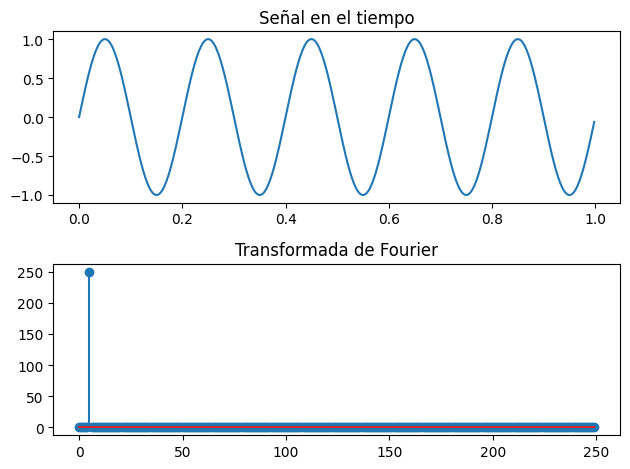

In [ ]:
#1. Transformada de Fourier (FT, DFT, FFT)
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 1, 500, endpoint=False)
f = 5  # Frecuencia en Hz
x = np.sin(2 * np.pi * f * t)

X = np.fft.fft(x)
freqs = np.fft.fftfreq(len(t), d=t[1]-t[0])

plt.subplot(2,1,1)
plt.plot(t, x)
plt.title("Señal en el tiempo")

plt.subplot(2,1,2)
plt.stem(freqs[:len(freqs)//2], np.abs(X[:len(X)//2]))
plt.title("Transformada de Fourier")
plt.tight_layout()
plt.show()


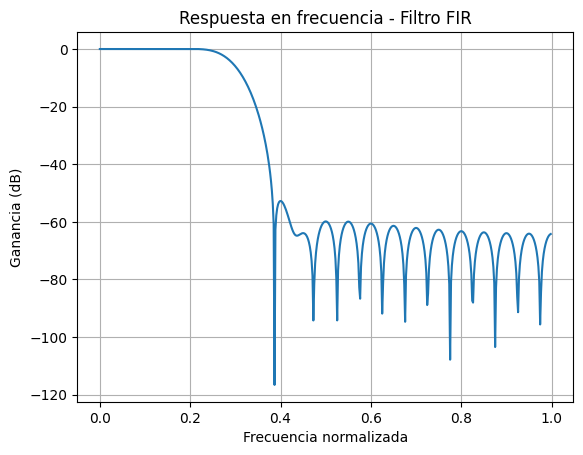

In [ ]:
#2. Filtrado Digital (FIR/IIR)
from scipy.signal import firwin, freqz
import matplotlib.pyplot as plt

fir_coeff = firwin(numtaps=41, cutoff=0.3)
w, h = freqz(fir_coeff)

plt.plot(w/np.pi, 20*np.log10(abs(h)))
plt.title("Respuesta en frecuencia - Filtro FIR")
plt.xlabel("Frecuencia normalizada")
plt.ylabel("Ganancia (dB)")
plt.grid()
plt.show()


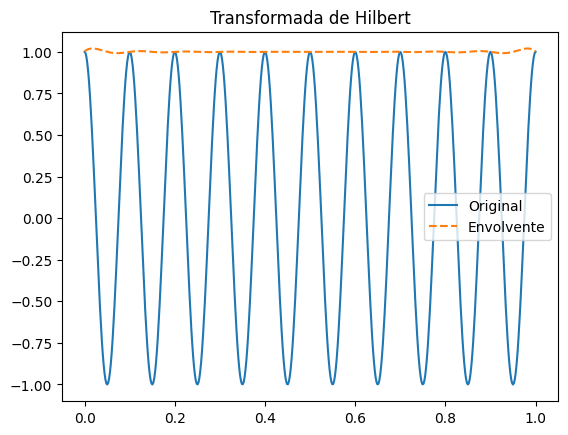

In [ ]:
#3Señales Analíticas y Transformada de Hilbert
from scipy.signal import hilbert

t = np.linspace(0, 1, 500)
s = np.cos(2*np.pi*10*t)
analytic_signal = hilbert(s)
amplitude_envelope = np.abs(analytic_signal)

plt.plot(t, s, label='Original')
plt.plot(t, amplitude_envelope, label='Envolvente', linestyle='--')
plt.legend()
plt.title("Transformada de Hilbert")
plt.show()


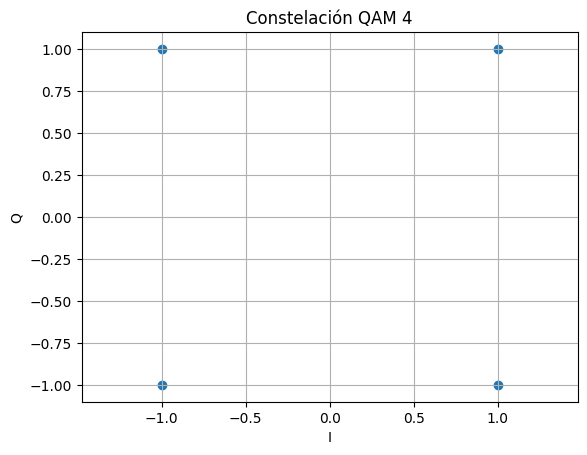

In [ ]:
#4Señales I/Q y Modulación QAM
import numpy as np
import matplotlib.pyplot as plt

qam_symbols = [complex(i, q) for i in [-1, 1] for q in [-1, 1]]
plt.scatter([s.real for s in qam_symbols], [s.imag for s in qam_symbols])
plt.title("Constelación QAM 4")
plt.grid()
plt.xlabel("I")
plt.ylabel("Q")
plt.axis('equal')
plt.show()


## Fase 1: Análisis en el Dominio de la Frecuencia
Esta fase tiene como objetivo generar una señal compuesta por varias frecuencias, aplicar la Transformada Rápida de Fourier (FFT) para observar su contenido espectral, diseñar y aplicar un filtro paso-bajo, y finalmente analizar la respuesta en frecuencia del filtro utilizando diagramas de Bode.

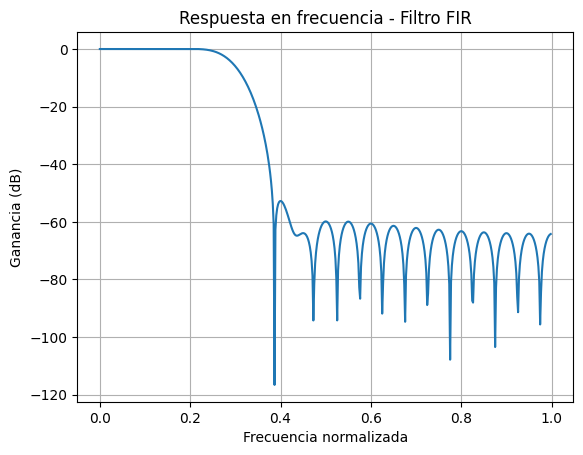

In [ ]:
#2. Filtrado Digital (FIR/IIR)
from scipy.signal import firwin, freqz
import matplotlib.pyplot as plt

fir_coeff = firwin(numtaps=41, cutoff=0.3)
w, h = freqz(fir_coeff)

plt.plot(w/np.pi, 20*np.log10(abs(h)))
plt.title("Respuesta en frecuencia - Filtro FIR")
plt.xlabel("Frecuencia normalizada")
plt.ylabel("Ganancia (dB)")
plt.grid()
plt.show()


### ✅ Paso 1: Generar señal compuesta
Se genera una señal sintética con tres componentes senoidales de diferentes frecuencias: 10 Hz, 50 Hz y 150 Hz.

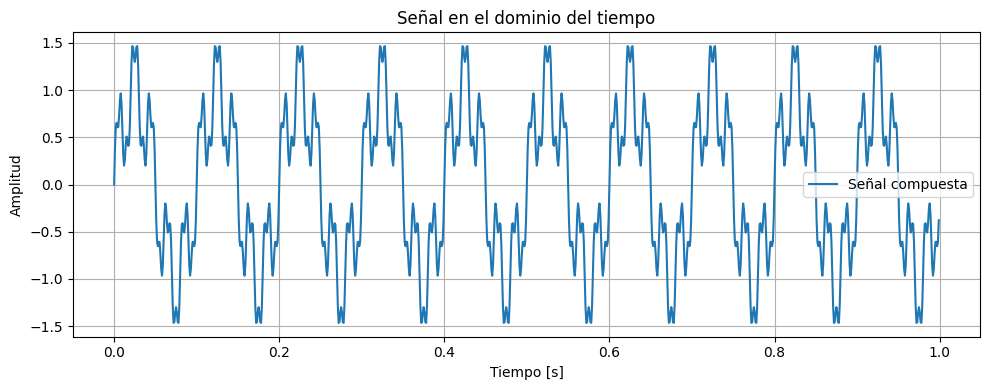

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de simulación
fs = 1000  # frecuencia de muestreo en Hz
T = 1      # duración de la señal en segundos
t = np.linspace(0, T, int(fs*T), endpoint=False)

# Componentes de la señal
f1, f2, f3 = 10, 50, 150  # frecuencias en Hz
signal = (np.sin(2*np.pi*f1*t) +
          0.5*np.sin(2*np.pi*f2*t) +
          0.2*np.sin(2*np.pi*f3*t))

# Gráfica de la señal en el dominio del tiempo
plt.figure(figsize=(10, 4))
plt.plot(t, signal, label='Señal compuesta')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Señal en el dominio del tiempo')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### ✅ Paso 2: Aplicar FFT a la señal
Se aplica la Transformada Rápida de Fourier para visualizar el contenido espectral de la señal.

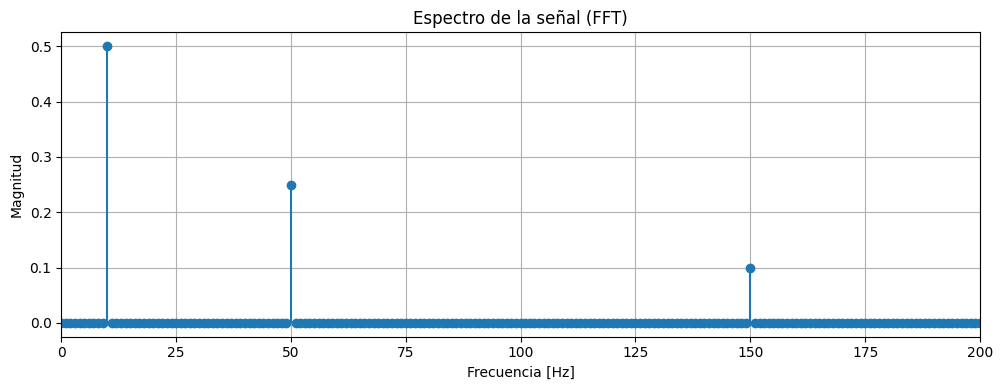

In [ ]:
# FFT
n = len(signal)
f = np.fft.fftfreq(n, 1/fs)
fft_values = np.fft.fft(signal)

# Magnitud normalizada
magnitude = np.abs(fft_values) / n

# Solo parte positiva del espectro
half_n = n // 2
f_plot = f[:half_n]
magnitude_plot = magnitude[:half_n]

# Gráfico espectral
plt.figure(figsize=(10, 4))
plt.stem(f_plot, magnitude_plot, basefmt=" ")
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud')
plt.title('Espectro de la señal (FFT)')
plt.grid(True)
plt.tight_layout()
plt.xlim(0, 200)
plt.show()

### ✅ Paso 3: Aplicar un filtro paso-bajo
Se diseña e implementa un filtro digital paso-bajo con una frecuencia de corte de 40 Hz para atenuar las componentes de alta frecuencia.

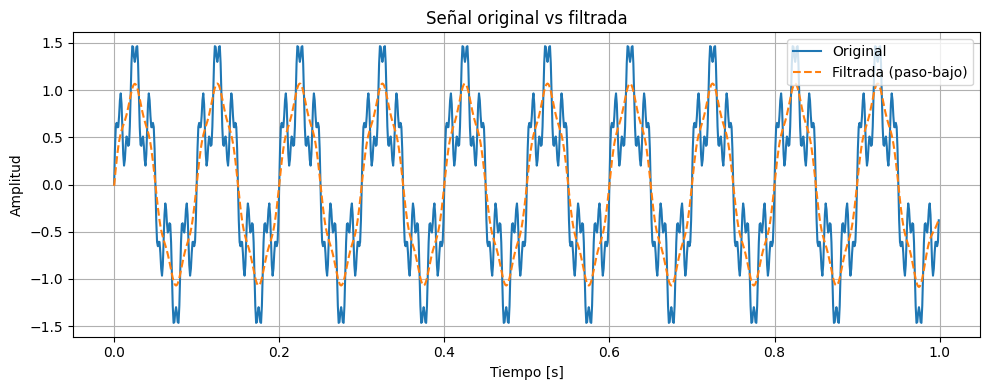

In [ ]:
from scipy.signal import butter, filtfilt

# Filtro paso-bajo de orden 4 con frecuencia de corte de 40 Hz
fc = 40  # frecuencia de corte
b, a = butter(N=4, Wn=fc/(fs/2), btype='low')
filtered_signal = filtfilt(b, a, signal)

# Gráfica señal original vs filtrada
plt.figure(figsize=(10, 4))
plt.plot(t, signal, label='Original')
plt.plot(t, filtered_signal, label='Filtrada (paso-bajo)', linestyle='--')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Señal original vs filtrada')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### ✅ Paso 4: Comparación de espectros
Se comparan los espectros (FFT) de la señal original y la filtrada para verificar el efecto del filtro.

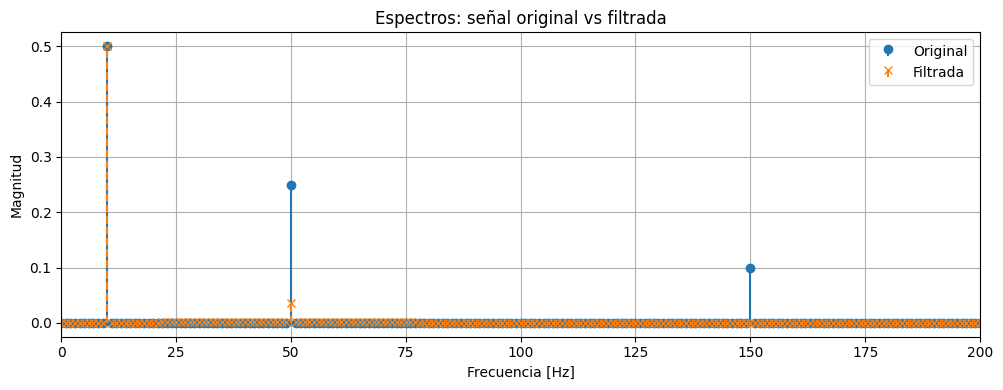

In [ ]:
# FFT de la señal filtrada
fft_filtered = np.fft.fft(filtered_signal)
magnitude_filtered = np.abs(fft_filtered) / n
magnitude_filtered_plot = magnitude_filtered[:half_n]

# Comparación de espectros
plt.figure(figsize=(10, 4))
plt.stem(f_plot, magnitude_plot, linefmt='C0-', markerfmt='C0o', basefmt=" ", label='Original')
plt.stem(f_plot, magnitude_filtered_plot, linefmt='C1--', markerfmt='C1x', basefmt=" ", label='Filtrada')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud')
plt.title('Espectros: señal original vs filtrada')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.xlim(0, 200)
plt.show()

### ✅ Paso 5: Diagramas de Bode del filtro
Se grafica la magnitud y la fase del filtro paso-bajo utilizando la función `freqz` de SciPy.

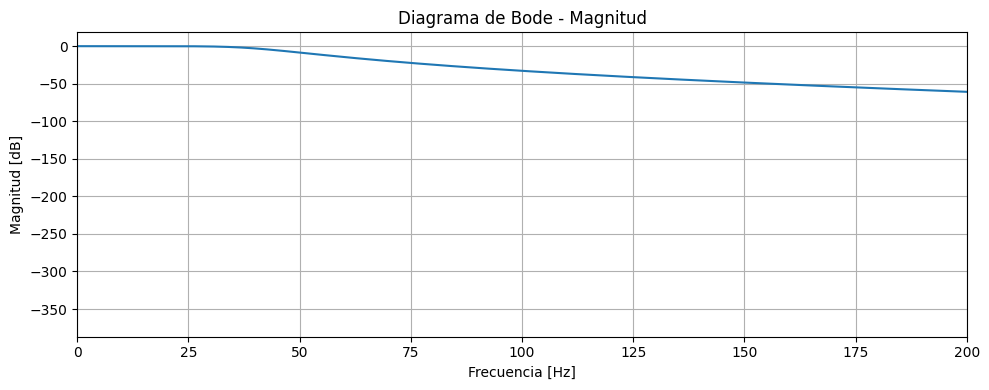

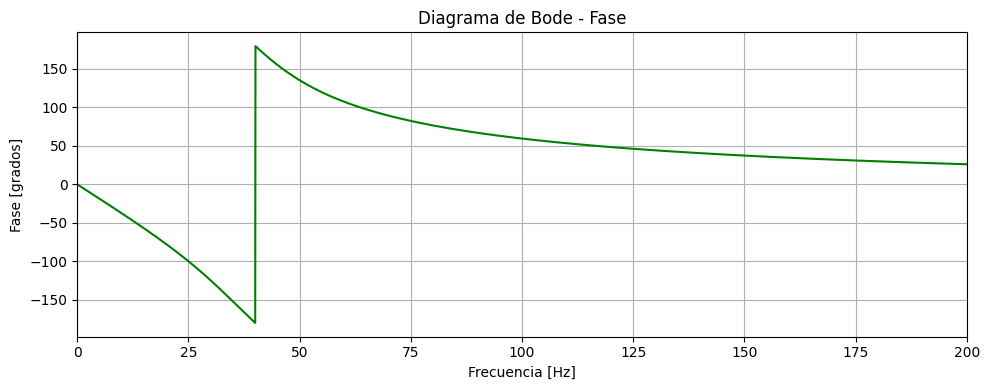

In [ ]:
from scipy.signal import freqz

# Obtener la respuesta en frecuencia del filtro
w, h = freqz(b, a, worN=8000)
frequencies = w * fs / (2 * np.pi)

# Gráfico de magnitud (Bode)
plt.figure(figsize=(10, 4))
plt.plot(frequencies, 20 * np.log10(abs(h)))
plt.title('Diagrama de Bode - Magnitud')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.grid(True)
plt.xlim(0, 200)
plt.tight_layout()
plt.show()

# Gráfico de fase (Bode)
plt.figure(figsize=(10, 4))
plt.plot(frequencies, np.angle(h, deg=True), color='green')
plt.title('Diagrama de Bode - Fase')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [grados]')
plt.grid(True)
plt.xlim(0, 200)
plt.tight_layout()
plt.show()

# Fase 2: Construcción de Señales I/Q
✅ 2. Visualizar el desfase entre I(t) y Q(t)

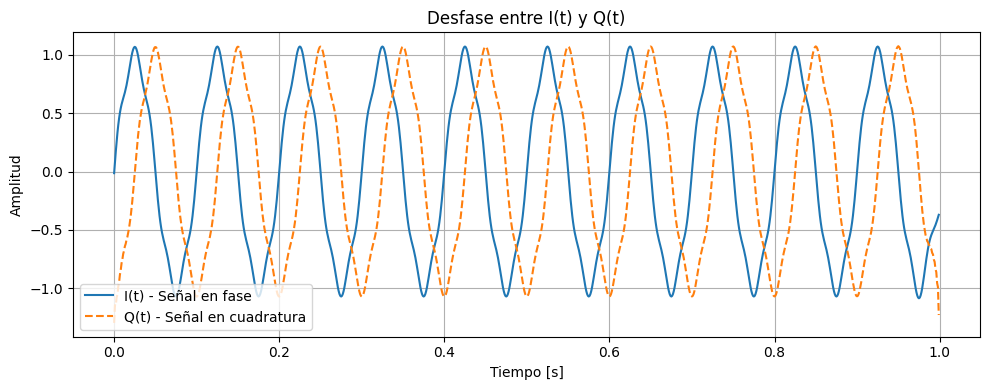

In [ ]:
from scipy.signal import hilbert
import matplotlib.pyplot as plt
import numpy as np

# Suponemos que 'filtered_signal', 't' y 'fs' ya están definidos (vienen de la Fase 1)
I_t = filtered_signal  # Señal mensaje
analytic_signal = hilbert(I_t)
Q_t = np.imag(analytic_signal)  # Señal en cuadratura
plt.figure(figsize=(10, 4))
plt.plot(t, I_t, label='I(t) - Señal en fase')
plt.plot(t, Q_t, label='Q(t) - Señal en cuadratura', linestyle='--')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Desfase entre I(t) y Q(t)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## ✅ Diagrama de Bode de la señal Q(t)

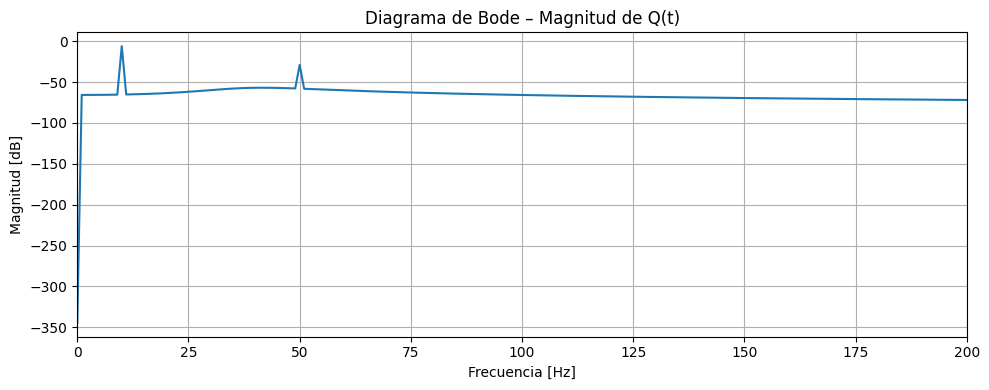

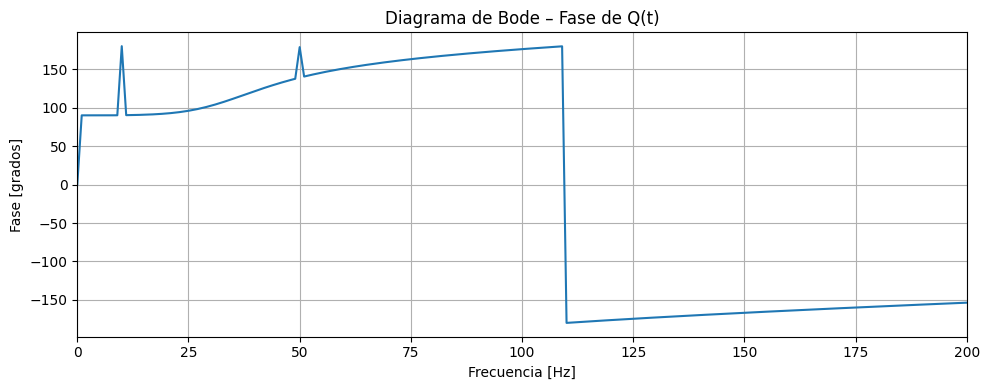

In [ ]:
# FFT de Q(t)
n = len(Q_t)
f = np.fft.fftfreq(n, 1/fs)
half_n = n // 2
f_plot = f[:half_n]

fft_Q = np.fft.fft(Q_t)
magnitude_Q = np.abs(fft_Q) / n
phase_Q = np.angle(fft_Q, deg=True)

# Graficar magnitud (en dB)
plt.figure(figsize=(10, 4))
plt.plot(f_plot, 20 * np.log10(magnitude_Q[:half_n]))
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.title('Diagrama de Bode – Magnitud de Q(t)')
plt.grid(True)
plt.xlim(0, 200)
plt.tight_layout()
plt.show()

# Graficar fase (en grados)
plt.figure(figsize=(10, 4))
plt.plot(f_plot, phase_Q[:half_n])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [grados]')
plt.title('Diagrama de Bode – Fase de Q(t)')
plt.grid(True)
plt.xlim(0, 200)
plt.tight_layout()
plt.show()


# FASE 3

##✅Paso 1: Generar símbolos y construir I(t), Q(t)


In [ ]:
import numpy as np

# Parámetros
num_symbols = 100  # número de símbolos 16-QAM
bits_per_symbol = 4
fs = 1000          # frecuencia de muestreo
symbol_rate = 100  # símbolos por segundo
samples_per_symbol = fs // symbol_rate

# 1. Generar bits aleatorios
num_bits = num_symbols * bits_per_symbol
bits = np.random.randint(0, 2, num_bits)

# 2. Agrupar de a 4 bits y mapear a coordenadas 16-QAM (Gray coding simple)
# Map: 2 bits → {-3, -1, +1, +3}
def bits_to_level(b1, b2):
    return -3 if (b1 == 0 and b2 == 0) else \
           -1 if (b1 == 0 and b2 == 1) else \
           +3 if (b1 == 1 and b2 == 0) else +1

I_symbols = []
Q_symbols = []

for i in range(0, num_bits, 4):
    b_I = bits[i:i+2]
    b_Q = bits[i+2:i+4]
    I_symbols.append(bits_to_level(*b_I))
    Q_symbols.append(bits_to_level(*b_Q))

I_symbols = np.array(I_symbols)
Q_symbols = np.array(Q_symbols)

# 3. Expandir símbolos en el tiempo (pulso rectangular por símbolo)
I_t = np.repeat(I_symbols, samples_per_symbol)
Q_t = np.repeat(Q_symbols, samples_per_symbol)

# Vector de tiempo total
T = len(I_t) / fs
t = np.linspace(0, T, len(I_t), endpoint=False)



## ✅ Paso 2: Modulación QAM – Señal real transmitida

La modulación en amplitud en cuadratura (QAM) combina las señales en fase y cuadratura utilizando una portadora de alta frecuencia. La señal modulada en tiempo continuo se define como:

$$
s(t) = I(t) \cdot \cos(2\pi f_c t) - Q(t) \cdot \sin(2\pi f_c t)
$$

donde:

$$
\begin{aligned}
I(t) &: \text{ señal en fase} \\
Q(t) &: \text{ señal en cuadratura} \\
f_c &: \text{ frecuencia de la portadora}
\end{aligned}
$$

Esta combinación permite transmitir simultáneamente dos flujos de información (I y Q) sobre una sola señal real, lo cual es fundamental en sistemas modernos como WiFi y 5G.


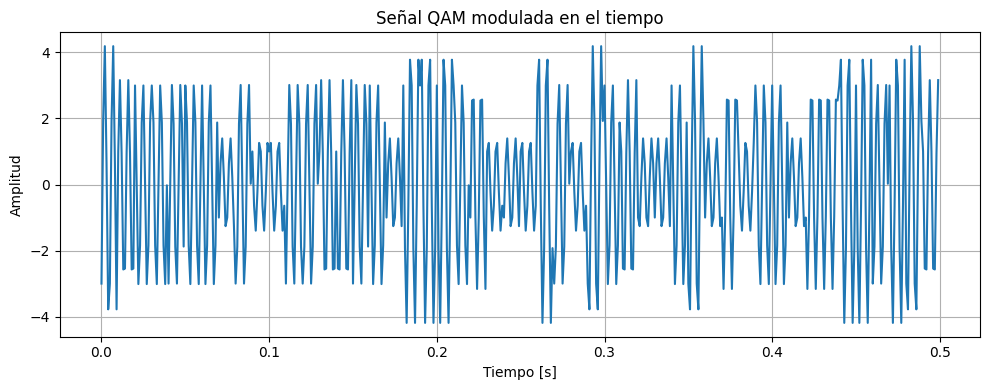

In [ ]:
import matplotlib.pyplot as plt

# Frecuencia de la portadora (mayor que symbol_rate)
fc = 200  # Hz

# Señal modulada
s_t = I_t * np.cos(2 * np.pi * fc * t) - Q_t * np.sin(2 * np.pi * fc * t)

# Visualizar señal QAM
plt.figure(figsize=(10, 4))
plt.plot(t[:500], s_t[:500])  # Mostrar solo primeros 500 puntos (~0.5 s)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Señal QAM modulada en el tiempo')
plt.grid(True)
plt.tight_layout()
plt.show()


## ✅ Paso 3: Análisis espectral de la señal QAM

$$

Al aplicar la FFT sobre \( s(t) \), se espera un espectro centrado en la frecuencia de la portadora \( f_c \), debido a la modulación. Esta transformación permite visualizar los componentes de frecuencia ocupados por la señal transmitida:

$$
S(f) = \mathcal{F}\{s(t)\}
$$


Donde $  \mathcal{F}\{\cdot\} $ es la transformada de Fourier.




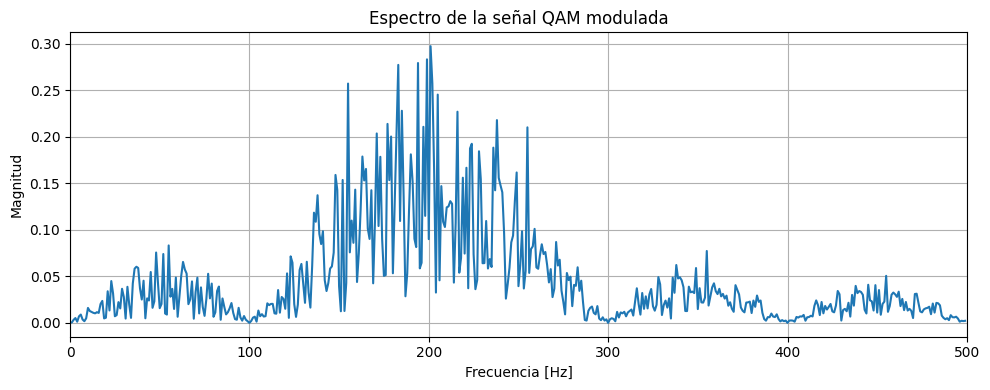

In [ ]:
# FFT de la señal QAM
n = len(s_t)
f = np.fft.fftfreq(n, 1/fs)
fft_s = np.fft.fft(s_t)
magnitude = np.abs(fft_s) / n

# Mostrar solo la mitad positiva del espectro
half_n = n // 2
f_plot = f[:half_n]
magnitude_plot = magnitude[:half_n]

# Graficar el espectro
plt.figure(figsize=(10, 4))
plt.plot(f_plot, magnitude_plot)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud')
plt.title('Espectro de la señal QAM modulada')
plt.grid(True)
plt.xlim(0, 500)  # limitar hasta 500 Hz para visualizar el entorno de fc
plt.tight_layout()
plt.show()


##✅ Paso 4: Diagrama de Constelación (I vs. Q)

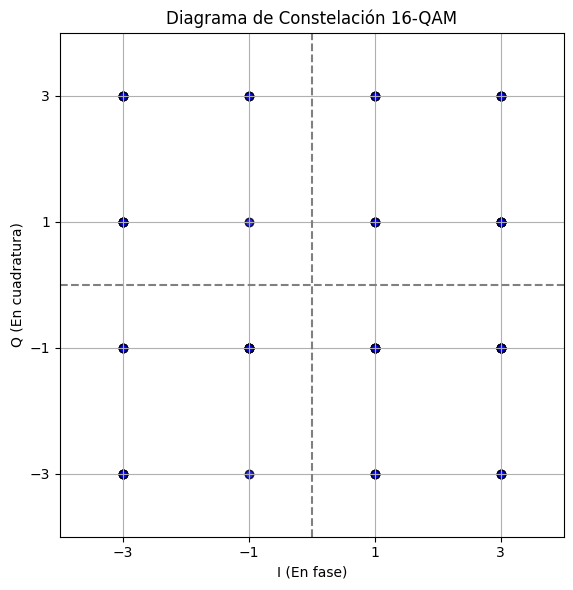

In [ ]:
# Graficar los símbolos en el plano I-Q (constelación)
plt.figure(figsize=(6, 6))
plt.scatter(I_symbols, Q_symbols, color='blue', alpha=0.6, edgecolors='k')
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.xlabel('I (En fase)')
plt.ylabel('Q (En cuadratura)')
plt.title('Diagrama de Constelación 16-QAM')
plt.grid(True)
plt.xticks([-3, -1, 1, 3])
plt.yticks([-3, -1, 1, 3])
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()
